<a href="https://colab.research.google.com/github/Samiya-AW/Mental-Health-Disorder-Classification-with-Random-Forest-and-XGBoost/blob/main/Mental_Health_Disorder_Classification_with_Random_Forestf_and_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install libraries

!pip install pandas scikit-learn matplotlib seaborn

In [ ]:
# Import libraries

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load data set

df = pd.read_excel('/content/data set/Mental disorder symptoms.xlsx')

# Clean and remove duplicate entries/data samples from data set file

df = df.dropna().drop_duplicates()

X = df.drop('Disorder', axis = 1)
y = df['Disorder']

# Divide the input features (X) and corresponding labels (y) into separate training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2, random_state= 42, stratify = y)     # X, y: These are the original feature and label arrays (or DataFrames) that you want to split.
                                                              # X_train, X_test, y_train, y_test: These are the four output variables that store the resulting subsets of the data.
                                                              # X_train and y_train are the feature and label data used to train the machine learning model.
                                                              # X_test and y_test are the feature and label data used to evaluate the model's performance on unseen data.

model = RandomForestClassifier(n_estimators= 100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy = ", accuracy_score(y_test, y_pred))
print("\n Classification Report: \n", classification_report(y_test, y_pred))

Accuracy =  0.9130434782608695

 Classification Report: 
                       precision    recall  f1-score   support

                ADHD       1.00      1.00      1.00         4
                 ASD       1.00      1.00      1.00         3
          Loneliness       1.00      1.00      1.00         1
                 MDD       0.50      0.50      0.50         2
                 OCD       1.00      1.00      1.00         1
                 PDD       0.50      0.50      0.50         2
                PTSD       1.00      1.00      1.00         2
            anexiety       1.00      1.00      1.00         2
             bipolar       1.00      1.00      1.00         1
     eating disorder       1.00      1.00      1.00         2
psychotic deprission       1.00      1.00      1.00         1
   sleeping disorder       1.00      1.00      1.00         2

            accuracy                           0.91        23
           macro avg       0.92      0.92      0.92        23
        we

In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X, y, cv = 5)
print("CV mean accuracy = ", cv_scores.mean())

CV mean accuracy =  0.9300395256916996


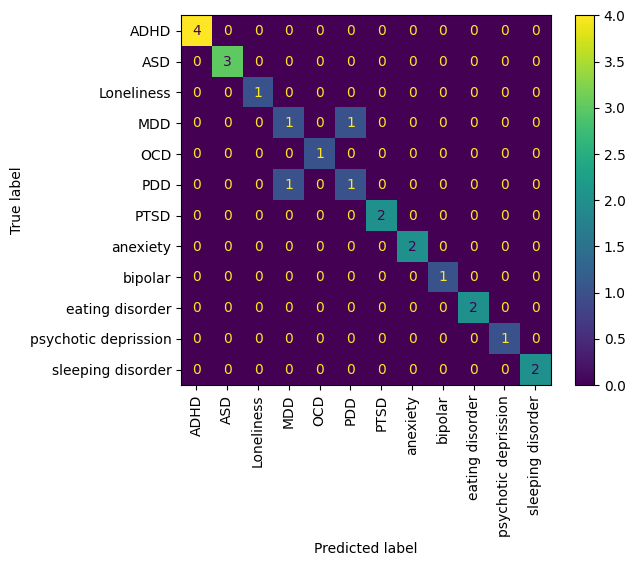

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, xticks_rotation = 90)

Test Accuracy:  0.9318181818181818

Classification Report: 
                       precision    recall  f1-score   support

                ADHD       1.00      1.00      1.00         3
                 ASD       1.00      1.00      1.00         4
          Loneliness       1.00      1.00      1.00         4
                 MDD       0.80      1.00      0.89         4
                 OCD       1.00      0.75      0.86         4
                 PDD       1.00      0.75      0.86         4
                PTSD       1.00      0.75      0.86         4
            anexiety       1.00      1.00      1.00         4
             bipolar       0.75      1.00      0.86         3
     eating disorder       1.00      1.00      1.00         3
psychotic deprission       1.00      1.00      1.00         3
   sleeping disorder       0.80      1.00      0.89         4

            accuracy                           0.93        44
           macro avg       0.95      0.94      0.93        44
       

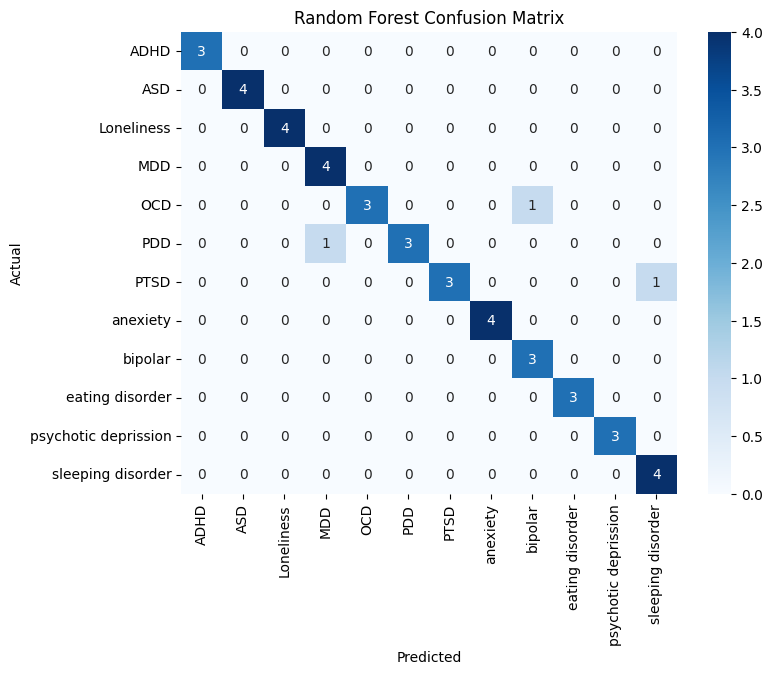

Cross-validation mean accuracy: 0.9584566596194503

Top 10 Important Features:
 introvert                      0.063457
increased.energy               0.059464
feeling.negative               0.052636
having.trouble.in.sleeping     0.051442
popping.up.stressful.memory    0.050826
avoids.people.or.activities    0.050480
close.friend                   0.048547
trouble.concentrating          0.046388
trouble.in.concentration       0.043227
hopelessness                   0.042488
dtype: float64


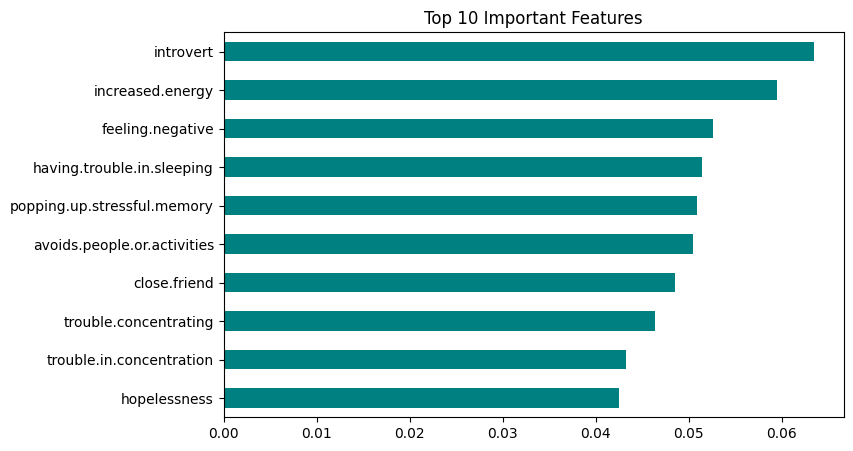


Best Hypermeters:  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

Best CV Score:  0.9675475687103594


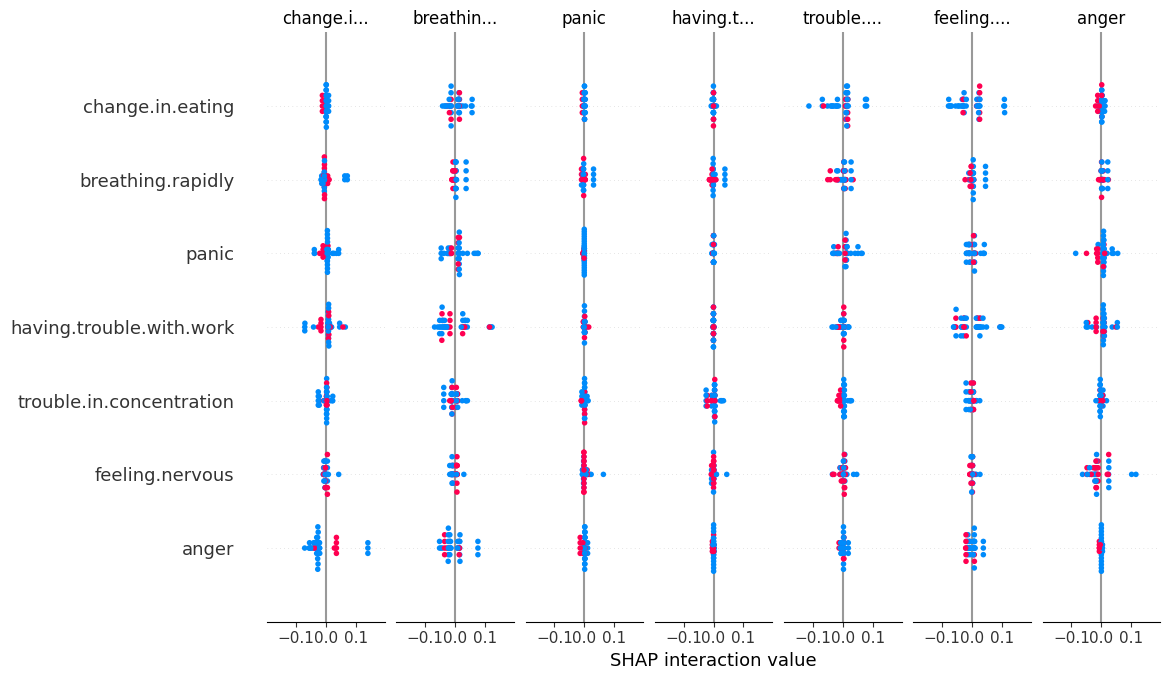

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV

smote = SMOTE(random_state = 42, k_neighbors = 4)     # Synthetic Minority Over-sampling Technique (SMOTE) from the imblearn library handles class imbalance in a dataset.
X_resampled, y_resampled = smote.fit_resample(X, y)   # It increases the number of minority class samples by generating new synthetic data points.
# fit_resample(X, y): This method takes your original, imbalanced feature set (X) and target labels (y), analyzes them,
# and generates synthetic samples to balance the class distribution.
# X_resampled, y_resampled: The result is a new, balanced dataset. The minority class will now have the same number of samples as the majority class.

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size = 0.2, random_state = 42, stratify = y_resampled)

model = RandomForestClassifier(n_estimators= 100, random_state= 42, class_weight= "balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Test Accuracy: ", accuracy_score(y_test, y_pred))
print("\nClassification Report: \n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap= "Blues",
            xticklabels = model.classes_,
            yticklabels = model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

cv_scores = cross_val_score(model, X_resampled, y_resampled, cv = 5)
print("Cross-validation mean accuracy:", cv_scores.mean())

importances = model.feature_importances_
feature_importance = pd.Series(importances, index = X.columns).sort_values(ascending = False)
print('\nTop 10 Important Features:\n', feature_importance.head(10))
plt.figure(figsize = (8, 5))
feature_importance.head(10).plot(kind = "barh", color = 'teal')
plt.title('Top 10 Important Features')
plt.gca().invert_yaxis()
plt.show()

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state = 42, class_weight= "balanced"),
    param_grid, cv = 5, scoring = "accuracy", n_jobs = -1
)

grid.fit(X_resampled, y_resampled)
print("\nBest Hypermeters: ", grid.best_params_)
print("\nBest CV Score: ", grid.best_score_)

import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names = X.columns)